In [3]:
!pip install opencv-python
!pip install openpyxl


  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)


In [2]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np

# Leer el archivo Excel
e1 = pd.read_excel('datos_procesados_empresa1_con_imagen.xlsx')


# Mostrar las primeras filas del DataFrame
e1.head()

,ORIG_STD_VOLUME,STD_VOLUME,ORIG_TEMPERATURE,TEMPERATURE,PRESSURE,ORIG_PRESSURE,ORIG_RAW_VOLUME,RAW_VOLUME,EFFECTIVE_DATE,image_filename
0,-2.029433,-2.027449,-1.006428,-1.006428,0.336045,0.336045,-2.164089,-2.161837,2018-09-03 09:00:00,Año2018_Día2018-09-03.png
1,-1.929310,-1.927454,-0.951826,-0.951826,0.369934,0.369934,0.647292,0.645791,2018-09-03 10:00:00,Año2018_Día2018-09-03.png
2,-1.920680,-1.918836,-0.885619,-0.885619,0.342728,0.342728,0.891760,0.889933,2018-09-03 11:00:00,Año2018_Día2018-09-03.png
3,-1.944717,-1.942842,-0.881222,-0.881222,0.375454,0.375454,0.212682,0.211762,2018-09-03 12:00:00,Año2018_Día2018-09-03.png
4,-1.948351,-1.946471,-0.881142,-0.881142,0.347026,0.347026,0.117611,0.116818,2018-09-03 13:00:00,Año2018_Día2018-09-03.png


In [3]:
# SCalcular el percentil 99 global para evitar que las anomalías dominen
global_max = np.percentile(e1["ORIG_RAW_VOLUME"], 99)
 
# Aplicar normalización dividiendo por ese valor máximo
e1["ORIG_RAW_VOLUME_NORM"] = e1["ORIG_RAW_VOLUME"] / global_max
e1["ORIG_RAW_VOLUME_NORM"] = np.clip(e1["ORIG_RAW_VOLUME_NORM"], 0, 1)

Skipping group with insufficient data: Año2019_Día2019-01-13.png
Epoch 1/20
49/49 [==============================] - 40s 678ms/step - loss: 0.5289 - accuracy: 0.7430 - val_loss: 0.5004 - val_accuracy: 0.7647
Epoch 2/20
49/49 [==============================] - 30s 624ms/step - loss: 0.4421 - accuracy: 0.7845 - val_loss: 0.4926 - val_accuracy: 0.7468
Epoch 3/20
49/49 [==============================] - 31s 640ms/step - loss: 0.4137 - accuracy: 0.8012 - val_loss: 0.4655 - val_accuracy: 0.7724
Epoch 4/20
49/49 [==============================] - 33s 684ms/step - loss: 0.4049 - accuracy: 0.8037 - val_loss: 0.4643 - val_accuracy: 0.7545
Epoch 5/20
49/49 [==============================] - 31s 629ms/step - loss: 0.4036 - accuracy: 0.8152 - val_loss: 0.5565 - val_accuracy: 0.7366
Epoch 6/20
49/49 [==============================] - 31s 625ms/step - loss: 0.3836 - accuracy: 0.8210 - val_loss: 0.4972 - val_accuracy: 0.7366
Epoch 7/20
49/49 [==============================] - 32s 655ms/step - loss: 0.

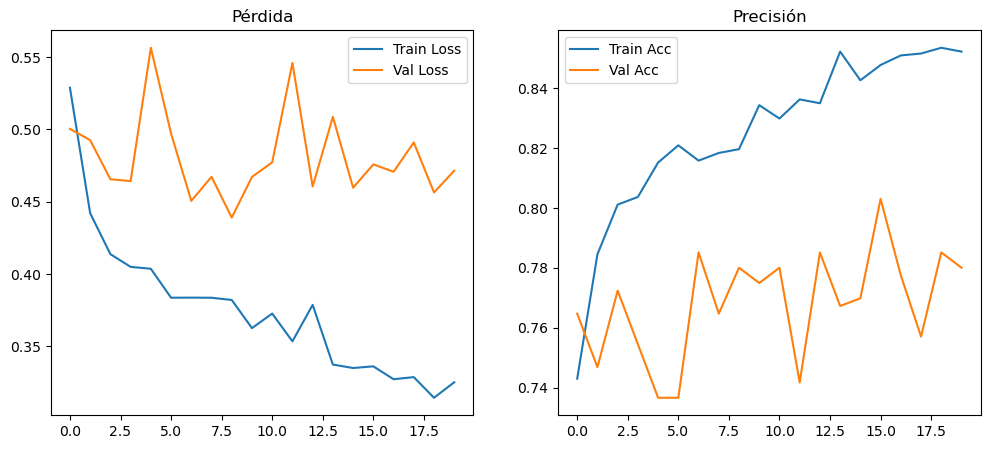

49/49 [==============================] - 40s 726ms/step

📊 Resultados para Train
Matriz de Confusión:
[[616 172]
 [ 58 718]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       788
           1       0.81      0.93      0.86       776

    accuracy                           0.85      1564
   macro avg       0.86      0.85      0.85      1564
weighted avg       0.86      0.85      0.85      1564



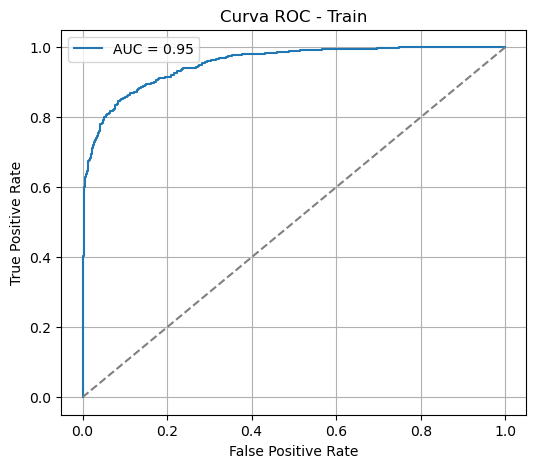

13/13 [==============================] - 10s 730ms/step

📊 Resultados para Test
Matriz de Confusión:
[[140  58]
 [ 28 165]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.71      0.77       198
           1       0.74      0.85      0.79       193

    accuracy                           0.78       391
   macro avg       0.79      0.78      0.78       391
weighted avg       0.79      0.78      0.78       391



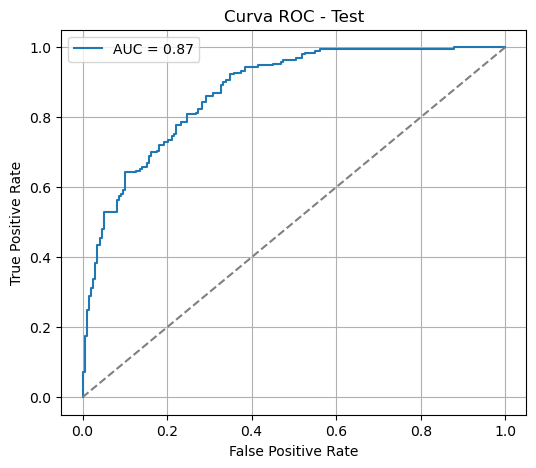

In [11]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, GlobalAveragePooling2D, Concatenate, Dropout
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc


# ==== CARGA DE DATOS ====
# Asegúrate de tener e1 ya cargado:
# e1 = pd.read_excel("datos_procesados_empresa1_con_imagen.xlsx")

# ==== CONFIGURACIÓN ====
img_base_dir = r"C:\Users\jupap\OneDrive - Universidad de los andes\Tesis Camiii\ProyectoGradoGEB\imagenes_diarias"  # 📌 Reemplaza con la ruta real
  # contiene las carpetas "normal" y "anomalo"
img_size = (224, 224)
batch_size = 32
epochs = 20

# ==== VARIABLES DE TIEMPO A USAR ====
features = ["STD_VOLUME", "ORIG_STD_VOLUME", "ORIG_TEMPERATURE", "TEMPERATURE",
            "PRESSURE", "ORIG_PRESSURE", "RAW_VOLUME", "ORIG_RAW_VOLUME"]
scaler = StandardScaler()
e1[features] = scaler.fit_transform(e1[features])

# ==== AGRUPACIÓN POR DÍA ====
X_img, X_seq, y = [], [], []

for name, group in e1.groupby("image_filename"):
    # Verificar si la imagen está en alguna carpeta
    img_path_normal = os.path.join(img_base_dir, "normal", name)
    img_path_anomalo = os.path.join(img_base_dir, "anomalo", name)

    if os.path.exists(img_path_anomalo):
        img_path = img_path_anomalo
        label = 1
    elif os.path.exists(img_path_normal):
        img_path = img_path_normal
        label = 0
    else:
        print(f"Image not found: {name}")
        continue  # imagen no encontrada
    
    with open(img_path, 'rb') as f:
        file_bytes = np.asarray(bytearray(f.read()), dtype=np.uint8)
        img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    if img is None: 
        print(f"Failed to load image: {img_path}")
        continue  # imagen dañada
    img = cv2.resize(img, img_size)
    img = img / 255.0

    # Datos de series de tiempo del día
    seq = group[features].values
    if seq.shape[0] < 6: 
        print(f"Skipping group with insufficient data: {name}")
        continue  # evitar días con muy pocas horas
    X_img.append(img)
    X_seq.append(seq)
    y.append(label)

# Check if data was loaded successfully
if len(X_img) == 0 or len(X_seq) == 0 or len(y) == 0:
    raise ValueError("No data was loaded. Please check the image paths and data preprocessing steps.")

# ==== CONVERTIR A NUMPY ====
X_img = np.array(X_img)
X_seq = tf.keras.preprocessing.sequence.pad_sequences(X_seq, padding="post", dtype="float32")
y = np.array(y)

# ==== DIVISIÓN ====
X_train_img, X_test_img, X_train_seq, X_test_seq, y_train, y_test = train_test_split(
    X_img, X_seq, y, test_size=0.2, random_state=42
)

# ==== MODELO CNN + LSTM ====
img_input = Input(shape=(224, 224, 3))
cnn_base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=img_input)
cnn_base.trainable = False
cnn_output = GlobalAveragePooling2D()(cnn_base.output)

seq_input = Input(shape=(X_seq.shape[1], X_seq.shape[2]))
lstm_output = LSTM(64)(seq_input)

fusion = Concatenate()([cnn_output, lstm_output])
x = Dense(128, activation="relu")(fusion)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=[img_input, seq_input], outputs=output)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# ==== ENTRENAMIENTO ====
history = model.fit(
    [X_train_img, X_train_seq], y_train,
    validation_data=([X_test_img, X_test_seq], y_test),
    epochs=epochs,
    batch_size=batch_size
)

# ==== GRÁFICAS DE PÉRDIDA Y PRECISIÓN ====
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Pérdida")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Precisión")
plt.legend()
plt.show()

# === MÉTRICAS EN TRAIN Y TEST ===
for name, X_img_set, X_seq_set, y_true in zip(
    ["Train", "Test"],
    [X_train_img, X_test_img],
    [X_train_seq, X_test_seq],
    [y_train, y_test]
):
    y_pred_proba = model.predict([X_img_set, X_seq_set])
    y_pred = (y_pred_proba > 0.5).astype(int)

    print(f"\n📊 Resultados para {name}")
    print("Matriz de Confusión:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    print("\nReporte de Clasificación:")
    print(classification_report(y_true, y_pred))

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title(f"Curva ROC - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()
    plt.show()


# ==== GUARDAR MODELO ====
model.save("modelo_cnn_lstm.h5")



=== Fold 1/5 ===
Epoch 1/20
49/49 [==============================] - 58s 1s/step - loss: 0.5215 - accuracy: 0.7347 - val_loss: 0.4960 - val_accuracy: 0.7621
Epoch 2/20
49/49 [==============================] - 43s 882ms/step - loss: 0.4410 - accuracy: 0.7909 - val_loss: 0.4736 - val_accuracy: 0.7724
Epoch 3/20
49/49 [==============================] - 41s 835ms/step - loss: 0.4280 - accuracy: 0.7845 - val_loss: 0.4643 - val_accuracy: 0.7673
Epoch 4/20
49/49 [==============================] - 42s 855ms/step - loss: 0.4007 - accuracy: 0.8082 - val_loss: 0.4719 - val_accuracy: 0.7801
Epoch 5/20
49/49 [==============================] - 45s 926ms/step - loss: 0.4201 - accuracy: 0.7858 - val_loss: 0.4805 - val_accuracy: 0.7749
Epoch 6/20
49/49 [==============================] - 42s 866ms/step - loss: 0.4050 - accuracy: 0.7954 - val_loss: 0.4901 - val_accuracy: 0.7724
Epoch 7/20
49/49 [==============================] - 40s 827ms/step - loss: 0.3860 - accuracy: 0.8210 - val_loss: 0.4753 - val_a

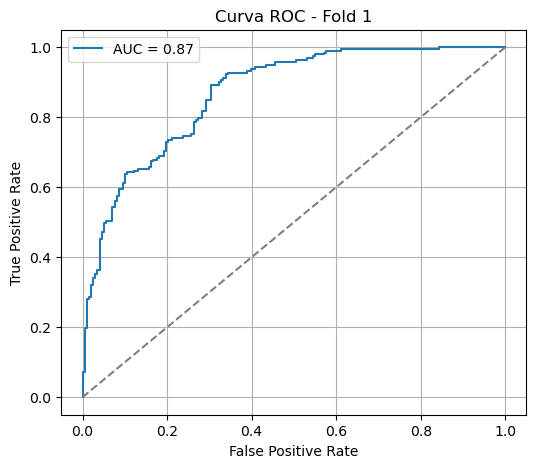


=== Fold 2/5 ===
Epoch 1/20
49/49 [==============================] - 69s 1s/step - loss: 0.5568 - accuracy: 0.7295 - val_loss: 0.4359 - val_accuracy: 0.8107
Epoch 2/20
49/49 [==============================] - 52s 1s/step - loss: 0.4466 - accuracy: 0.7717 - val_loss: 0.5058 - val_accuracy: 0.7340
Epoch 3/20
49/49 [==============================] - 50s 1s/step - loss: 0.4506 - accuracy: 0.7762 - val_loss: 0.4216 - val_accuracy: 0.8056
Epoch 4/20
49/49 [==============================] - 47s 965ms/step - loss: 0.4265 - accuracy: 0.7877 - val_loss: 0.4255 - val_accuracy: 0.7877
Epoch 5/20
49/49 [==============================] - 47s 965ms/step - loss: 0.4194 - accuracy: 0.7922 - val_loss: 0.4124 - val_accuracy: 0.8286
Epoch 6/20
49/49 [==============================] - 48s 982ms/step - loss: 0.4195 - accuracy: 0.7999 - val_loss: 0.4164 - val_accuracy: 0.7980
Epoch 7/20
49/49 [==============================] - 52s 1s/step - loss: 0.3906 - accuracy: 0.8171 - val_loss: 0.3989 - val_accuracy: 

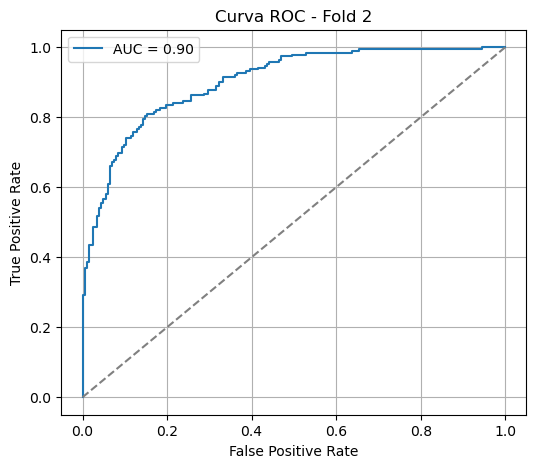


=== Fold 3/5 ===
Epoch 1/20
49/49 [==============================] - 55s 966ms/step - loss: 0.5391 - accuracy: 0.7199 - val_loss: 0.4672 - val_accuracy: 0.7801
Epoch 2/20
49/49 [==============================] - 46s 943ms/step - loss: 0.4353 - accuracy: 0.7980 - val_loss: 0.5191 - val_accuracy: 0.7084
Epoch 3/20
49/49 [==============================] - 47s 968ms/step - loss: 0.4273 - accuracy: 0.7916 - val_loss: 0.4732 - val_accuracy: 0.7596
Epoch 4/20
49/49 [==============================] - 60s 1s/step - loss: 0.4126 - accuracy: 0.8107 - val_loss: 0.5005 - val_accuracy: 0.7340
Epoch 5/20
49/49 [==============================] - 49s 1s/step - loss: 0.4049 - accuracy: 0.8031 - val_loss: 0.4387 - val_accuracy: 0.7749
Epoch 6/20
49/49 [==============================] - 43s 877ms/step - loss: 0.4084 - accuracy: 0.8018 - val_loss: 0.4397 - val_accuracy: 0.7928
Epoch 7/20
49/49 [==============================] - 38s 772ms/step - loss: 0.3844 - accuracy: 0.8171 - val_loss: 0.4648 - val_accu

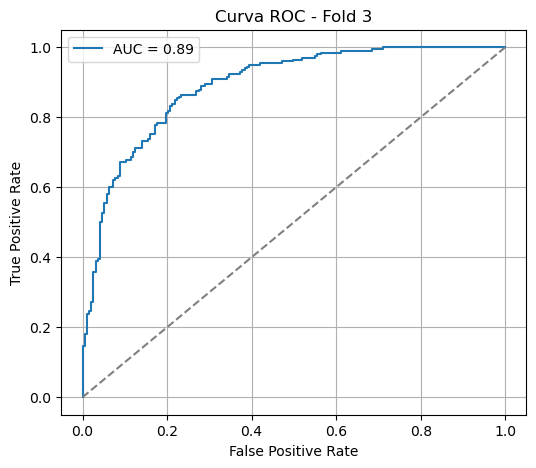


=== Fold 4/5 ===
Epoch 1/20
49/49 [==============================] - 45s 769ms/step - loss: 0.6113 - accuracy: 0.6816 - val_loss: 0.4714 - val_accuracy: 0.7673
Epoch 2/20
49/49 [==============================] - 32s 658ms/step - loss: 0.4790 - accuracy: 0.7717 - val_loss: 0.4630 - val_accuracy: 0.7621
Epoch 3/20
49/49 [==============================] - 33s 669ms/step - loss: 0.4459 - accuracy: 0.7839 - val_loss: 0.4141 - val_accuracy: 0.8107
Epoch 4/20
49/49 [==============================] - 32s 652ms/step - loss: 0.4364 - accuracy: 0.7954 - val_loss: 0.3944 - val_accuracy: 0.8082
Epoch 5/20
49/49 [==============================] - 32s 648ms/step - loss: 0.4151 - accuracy: 0.7954 - val_loss: 0.3932 - val_accuracy: 0.8005
Epoch 6/20
49/49 [==============================] - 32s 664ms/step - loss: 0.4115 - accuracy: 0.7967 - val_loss: 0.3930 - val_accuracy: 0.7980
Epoch 7/20
49/49 [==============================] - 32s 657ms/step - loss: 0.4004 - accuracy: 0.8107 - val_loss: 0.3854 - va

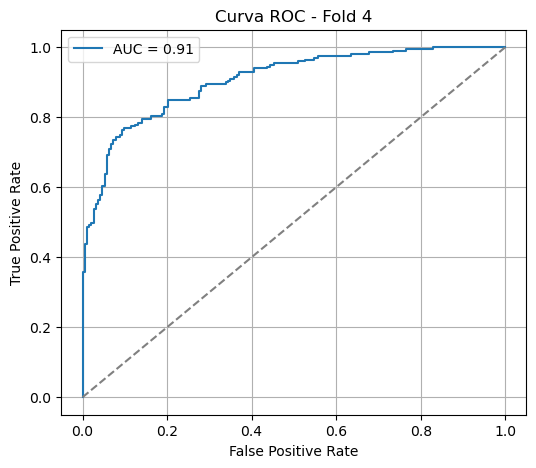


=== Fold 5/5 ===
Epoch 1/20
49/49 [==============================] - 54s 989ms/step - loss: 0.5751 - accuracy: 0.7033 - val_loss: 0.4085 - val_accuracy: 0.7980
Epoch 2/20
49/49 [==============================] - 34s 691ms/step - loss: 0.4735 - accuracy: 0.7558 - val_loss: 0.3948 - val_accuracy: 0.8235
Epoch 3/20
49/49 [==============================] - 36s 737ms/step - loss: 0.4573 - accuracy: 0.7660 - val_loss: 0.3847 - val_accuracy: 0.8005
Epoch 4/20
49/49 [==============================] - 37s 766ms/step - loss: 0.4287 - accuracy: 0.7941 - val_loss: 0.3401 - val_accuracy: 0.8363
Epoch 5/20
49/49 [==============================] - 34s 707ms/step - loss: 0.4165 - accuracy: 0.7967 - val_loss: 0.3993 - val_accuracy: 0.8056
Epoch 6/20
49/49 [==============================] - 37s 750ms/step - loss: 0.4133 - accuracy: 0.8018 - val_loss: 0.3580 - val_accuracy: 0.8210
Epoch 7/20
49/49 [==============================] - 36s 741ms/step - loss: 0.4088 - accuracy: 0.8024 - val_loss: 0.4120 - va

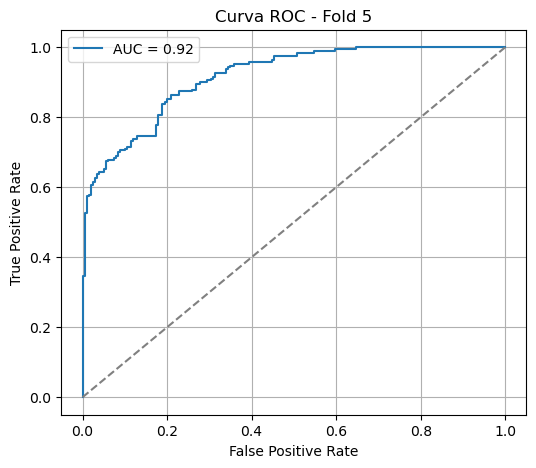


📊 Resultados Cross-Validation:
Fold 1: 0.7494
Fold 2: 0.7954
Fold 3: 0.8056
Fold 4: 0.8184
Fold 5: 0.8235

🔁 Promedio: 0.7985 ± 0.0265


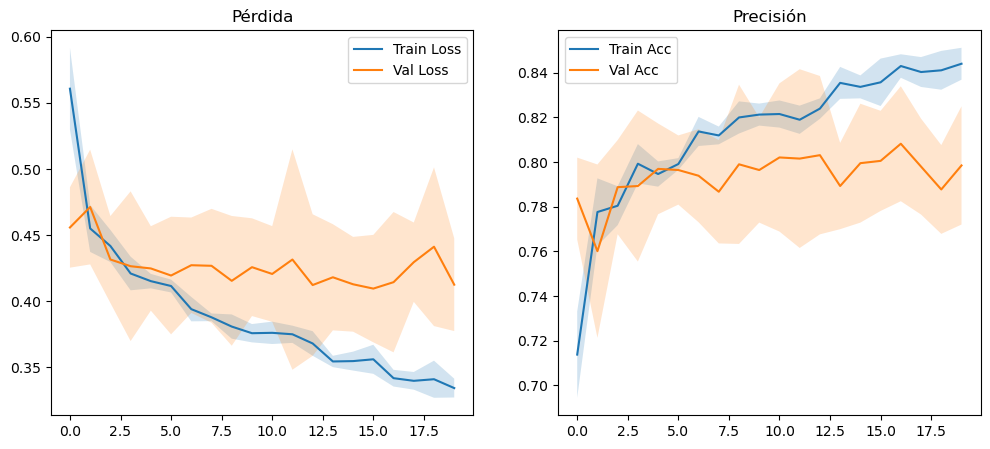

In [15]:
import os
import cv2
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, GlobalAveragePooling2D, Concatenate, Dropout
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, accuracy_score

# ==== CARGA DE DATOS ====
e1 = pd.read_excel("datos_procesados_empresa1_con_imagen.xlsx")

# ==== CONFIGURACIÓN ====
img_base_dir = r"C:\Users\jupap\OneDrive - Universidad de los andes\Tesis Camiii\ProyectoGradoGEB\imagenes_diarias"
img_size = (224, 224)
batch_size = 32
epochs = 20
k_folds = 5

# ==== VARIABLES DE TIEMPO ====
features = ["STD_VOLUME", "ORIG_STD_VOLUME", "ORIG_TEMPERATURE", "TEMPERATURE",
            "PRESSURE", "ORIG_PRESSURE", "RAW_VOLUME", "ORIG_RAW_VOLUME"]
scaler = StandardScaler()
e1[features] = scaler.fit_transform(e1[features])

# ==== PREPARACIÓN DE DATOS ====
X_img, X_seq, y = [], [], []

for name, group in e1.groupby("image_filename"):
    img_path_normal = os.path.join(img_base_dir, "normal", name)
    img_path_anomalo = os.path.join(img_base_dir, "anomalo", name)

    if os.path.exists(img_path_anomalo):
        img_path = img_path_anomalo
        label = 1
    elif os.path.exists(img_path_normal):
        img_path = img_path_normal
        label = 0
    else:
        continue

    with open(img_path, 'rb') as f:
        file_bytes = np.asarray(bytearray(f.read()), dtype=np.uint8)
        img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    if img is None:
        continue
    img = cv2.resize(img, img_size)
    img = img / 255.0

    seq = group[features].values
    if seq.shape[0] < 6:
        continue

    X_img.append(img)
    X_seq.append(seq)
    y.append(label)

if len(X_img) == 0:
    raise ValueError("No se cargaron datos.")

# ==== CONVERTIR A NUMPY ====
X_img = np.array(X_img)
X_seq = tf.keras.preprocessing.sequence.pad_sequences(X_seq, padding="post", dtype="float32")
y = np.array(y)

# ==== CROSS VALIDATION ====
kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
all_scores = []
histories = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_img)):
    print(f"\n=== Fold {fold+1}/{k_folds} ===")

    X_train_img, X_val_img = X_img[train_idx], X_img[val_idx]
    X_train_seq, X_val_seq = X_seq[train_idx], X_seq[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    img_input = Input(shape=(224, 224, 3))
    cnn_base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=img_input)
    cnn_base.trainable = False
    cnn_output = GlobalAveragePooling2D()(cnn_base.output)

    seq_input = Input(shape=(X_seq.shape[1], X_seq.shape[2]))
    lstm_output = LSTM(64)(seq_input)

    fusion = Concatenate()([cnn_output, lstm_output])
    x = Dense(128, activation="relu")(fusion)
    x = Dropout(0.3)(x)
    output = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=[img_input, seq_input], outputs=output)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    history = model.fit(
        [X_train_img, X_train_seq], y_train,
        validation_data=([X_val_img, X_val_seq], y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )

    histories.append(history.history)

    y_val_proba = model.predict([X_val_img, X_val_seq])
    y_val_pred = (y_val_proba > 0.5).astype(int)

    acc = accuracy_score(y_val, y_val_pred)
    all_scores.append(acc)
    print(f"✅ Accuracy del Fold {fold+1}: {acc:.4f}")

    cm = confusion_matrix(y_val, y_val_pred)
    print("Matriz de Confusión:")
    print(cm)
    print("\nReporte de Clasificación:")
    print(classification_report(y_val, y_val_pred))

    fpr, tpr, _ = roc_curve(y_val, y_val_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title(f"Curva ROC - Fold {fold+1}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()
    plt.show()

    tf.keras.backend.clear_session()
    gc.collect()

# ==== RESULTADOS GENERALES ====
print("\n📊 Resultados Cross-Validation:")
for i, acc in enumerate(all_scores):
    print(f"Fold {i+1}: {acc:.4f}")
print(f"\n🔁 Promedio: {np.mean(all_scores):.4f} ± {np.std(all_scores):.4f}")

# ==== GRÁFICA COMBINADA PROMEDIO LOSS Y ACCURACY ====
def plot_combined_metrics(histories):
    max_epochs = min(len(h["loss"]) for h in histories)

    train_loss = np.array([h["loss"][:max_epochs] for h in histories])
    val_loss = np.array([h["val_loss"][:max_epochs] for h in histories])
    train_acc = np.array([h["accuracy"][:max_epochs] for h in histories])
    val_acc = np.array([h["val_accuracy"][:max_epochs] for h in histories])

    fig, axs = plt.subplots(1, 2, figsize=(12, 5))

    # Loss
    mean_train_loss = train_loss.mean(axis=0)
    std_train_loss = train_loss.std(axis=0)
    mean_val_loss = val_loss.mean(axis=0)
    std_val_loss = val_loss.std(axis=0)

    axs[0].plot(mean_train_loss, label="Train Loss")
    axs[0].fill_between(range(max_epochs), mean_train_loss - std_train_loss, mean_train_loss + std_train_loss, alpha=0.2)
    axs[0].plot(mean_val_loss, label="Val Loss")
    axs[0].fill_between(range(max_epochs), mean_val_loss - std_val_loss, mean_val_loss + std_val_loss, alpha=0.2)
    axs[0].set_title("Pérdida")
    axs[0].legend()

    # Accuracy
    mean_train_acc = train_acc.mean(axis=0)
    std_train_acc = train_acc.std(axis=0)
    mean_val_acc = val_acc.mean(axis=0)
    std_val_acc = val_acc.std(axis=0)

    axs[1].plot(mean_train_acc, label="Train Acc")
    axs[1].fill_between(range(max_epochs), mean_train_acc - std_train_acc, mean_train_acc + std_train_acc, alpha=0.2)
    axs[1].plot(mean_val_acc, label="Val Acc")
    axs[1].fill_between(range(max_epochs), mean_val_acc - std_val_acc, mean_val_acc + std_val_acc, alpha=0.2)
    axs[1].set_title("Precisión")
    axs[1].legend()

    plt.show()

# LLAMAR LA GRÁFICA
plot_combined_metrics(histories)


Skipping group with insufficient data: Año2019_Día2019-01-13.png
Epoch 1/20
40/40 [==============================] - 36s 763ms/step - loss: 0.6181 - accuracy: 0.6715 - val_loss: 0.5367 - val_accuracy: 0.7125
Epoch 2/20
40/40 [==============================] - 26s 649ms/step - loss: 0.4682 - accuracy: 0.7802 - val_loss: 0.4304 - val_accuracy: 0.8147
Epoch 3/20
40/40 [==============================] - 28s 703ms/step - loss: 0.4516 - accuracy: 0.7770 - val_loss: 0.4471 - val_accuracy: 0.7859
Epoch 4/20
40/40 [==============================] - 28s 699ms/step - loss: 0.4357 - accuracy: 0.7882 - val_loss: 0.4179 - val_accuracy: 0.8211
Epoch 5/20
40/40 [==============================] - 31s 792ms/step - loss: 0.4087 - accuracy: 0.8034 - val_loss: 0.4310 - val_accuracy: 0.7987
Epoch 6/20
40/40 [==============================] - 26s 645ms/step - loss: 0.4053 - accuracy: 0.8018 - val_loss: 0.3854 - val_accuracy: 0.8243
Epoch 7/20
40/40 [==============================] - 29s 722ms/step - loss: 0.

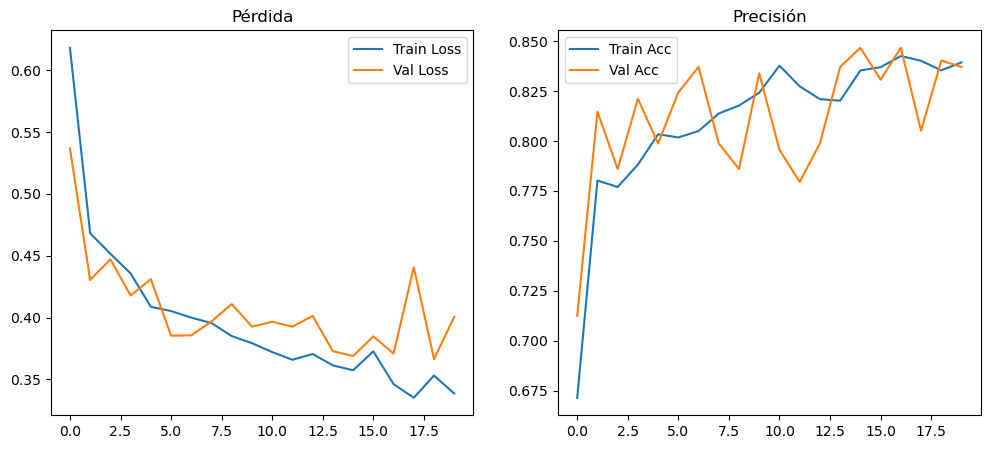

40/40 [==============================] - 22s 495ms/step

📊 Resultados para Train
Matriz de Confusión:
[[571  67]
 [116 497]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       638
           1       0.88      0.81      0.84       613

    accuracy                           0.85      1251
   macro avg       0.86      0.85      0.85      1251
weighted avg       0.86      0.85      0.85      1251



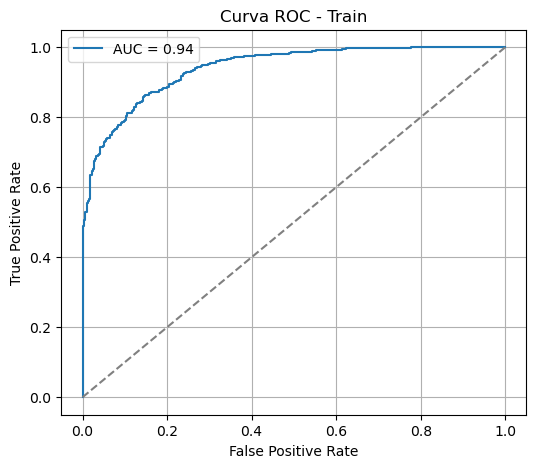

13/13 [==============================] - 6s 483ms/step

📊 Resultados para Test
Matriz de Confusión:
[[167  31]
 [ 61 132]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.73      0.84      0.78       198
           1       0.81      0.68      0.74       193

    accuracy                           0.76       391
   macro avg       0.77      0.76      0.76       391
weighted avg       0.77      0.76      0.76       391



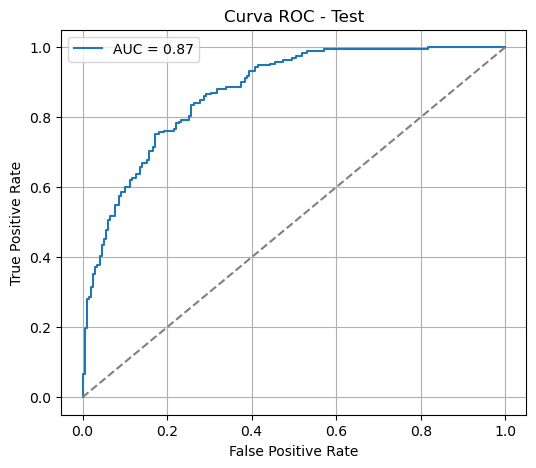

In [5]:
#CORRER -> CON COMENTARIO DE JUAN FERNANDO

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, GlobalAveragePooling2D, Concatenate, Dropout
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# ==== CARGA DE DATOS ====
# Asegúrate de tener e1 ya cargado:
# e1 = pd.read_excel("datos_procesados_empresa1_con_imagen.xlsx")

# ==== CONFIGURACIÓN ====
img_base_dir = r"C:\Users\jupap\OneDrive - Universidad de los andes\Tesis Camiii\ProyectoGradoGEB\imagenes_diarias"  # 📌 Reemplaza con la ruta real
img_size = (224, 224)
batch_size = 32
epochs = 20

# ==== VARIABLES DE TIEMPO A USAR ====
features = ["STD_VOLUME", "ORIG_STD_VOLUME", "ORIG_TEMPERATURE", "TEMPERATURE",
            "PRESSURE", "ORIG_PRESSURE", "RAW_VOLUME", "ORIG_RAW_VOLUME"]
scaler = StandardScaler()
e1[features] = scaler.fit_transform(e1[features])

# ==== AGRUPACIÓN POR DÍA ====
X_img, X_seq, y = [], [], []

for name, group in e1.groupby("image_filename"):
    img_path_normal = os.path.join(img_base_dir, "normal", name)
    img_path_anomalo = os.path.join(img_base_dir, "anomalo", name)

    if os.path.exists(img_path_anomalo):
        img_path = img_path_anomalo
        label = 1
    elif os.path.exists(img_path_normal):
        img_path = img_path_normal
        label = 0
    else:
        print(f"Image not found: {name}")
        continue
    
    with open(img_path, 'rb') as f:
        file_bytes = np.asarray(bytearray(f.read()), dtype=np.uint8)
        img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    if img is None: 
        print(f"Failed to load image: {img_path}")
        continue
    img = cv2.resize(img, img_size)
    img = img / 255.0

    seq = group[features].values
    if seq.shape[0] < 6: 
        print(f"Skipping group with insufficient data: {name}")
        continue
    X_img.append(img)
    X_seq.append(seq)
    y.append(label)

# Check if data was loaded successfully
if len(X_img) == 0 or len(X_seq) == 0 or len(y) == 0:
    raise ValueError("No data was loaded. Please check the image paths and data preprocessing steps.")

# ==== CONVERTIR A NUMPY ====
X_img = np.array(X_img)
X_seq = tf.keras.preprocessing.sequence.pad_sequences(X_seq, padding="post", dtype="float32")
y = np.array(y)

# ==== DIVISIÓN DE DATOS ====
# Primero: entrenamiento + prueba
X_train_img, X_test_img, X_train_seq, X_test_seq, y_train, y_test = train_test_split(
    X_img, X_seq, y, test_size=0.2, random_state=42
)

# Segundo: subdivisión entrenamiento → entrenamiento + validación
X_train_img, X_val_img, X_train_seq, X_val_seq, y_train, y_val = train_test_split(
    X_train_img, X_train_seq, y_train, test_size=0.2, random_state=42
)

# ==== MODELO CNN + LSTM ====
img_input = Input(shape=(224, 224, 3))
cnn_base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=img_input)
cnn_base.trainable = False
cnn_output = GlobalAveragePooling2D()(cnn_base.output)

seq_input = Input(shape=(X_seq.shape[1], X_seq.shape[2]))
lstm_output = LSTM(64)(seq_input)

fusion = Concatenate()([cnn_output, lstm_output])
x = Dense(128, activation="relu")(fusion)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=[img_input, seq_input], outputs=output)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# ==== ENTRENAMIENTO ====
history = model.fit(
    [X_train_img, X_train_seq], y_train,
    validation_data=([X_val_img, X_val_seq], y_val),
    epochs=epochs,
    batch_size=batch_size
)

# ==== GRÁFICAS DE PÉRDIDA Y PRECISIÓN ====
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Pérdida")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Precisión")
plt.legend()
plt.show()

# === MÉTRICAS EN TRAIN Y TEST ===
for name, X_img_set, X_seq_set, y_true in zip(
    ["Train", "Test"],
    [X_train_img, X_test_img],
    [X_train_seq, X_test_seq],
    [y_train, y_test]
):
    y_pred_proba = model.predict([X_img_set, X_seq_set])
    y_pred = (y_pred_proba > 0.5).astype(int)

    print(f"\n📊 Resultados para {name}")
    print("Matriz de Confusión:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    print("\nReporte de Clasificación:")
    print(classification_report(y_true, y_pred))

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title(f"Curva ROC - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()
    plt.show()

# ==== GUARDAR MODELO ====
model.save("modelo_cnn_lstm_v2.h5")

✅ Entrenamiento puro: 1252
🔍 Validación: 312
🧪 Prueba: 391
Epoch 1/20
40/40 [==============================] - 41s 837ms/step - loss: 0.5908 - accuracy: 0.6933 - val_loss: 0.4752 - val_accuracy: 0.7917
Epoch 2/20
40/40 [==============================] - 28s 706ms/step - loss: 0.4698 - accuracy: 0.7788 - val_loss: 0.4584 - val_accuracy: 0.7885
Epoch 3/20
40/40 [==============================] - 30s 762ms/step - loss: 0.4255 - accuracy: 0.7899 - val_loss: 0.5400 - val_accuracy: 0.7404
Epoch 4/20
40/40 [==============================] - 29s 738ms/step - loss: 0.4355 - accuracy: 0.7819 - val_loss: 0.4530 - val_accuracy: 0.7949
Epoch 5/20
40/40 [==============================] - 31s 787ms/step - loss: 0.4150 - accuracy: 0.7931 - val_loss: 0.5247 - val_accuracy: 0.7436
Epoch 6/20
40/40 [==============================] - 28s 706ms/step - loss: 0.4273 - accuracy: 0.7971 - val_loss: 0.4231 - val_accuracy: 0.8045
Epoch 7/20
40/40 [==============================] - 30s 764ms/step - loss: 0.3973 -

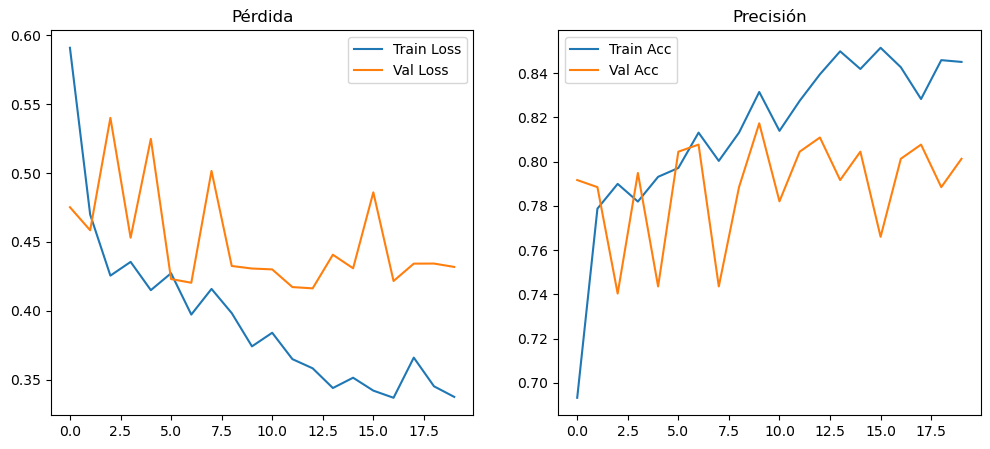


🔍 Evaluación en VALIDACIÓN
10/10 [==============================] - 7s 545ms/step
Matriz de confusión:
[[127  35]
 [ 27 123]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.82      0.78      0.80       162
           1       0.78      0.82      0.80       150

    accuracy                           0.80       312
   macro avg       0.80      0.80      0.80       312
weighted avg       0.80      0.80      0.80       312



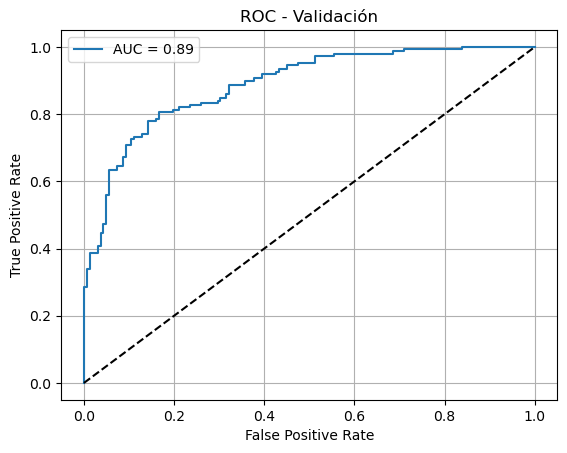


🧪 Evaluación en PRUEBA
13/13 [==============================] - 6s 420ms/step
Matriz de confusión:
[[160  38]
 [ 42 151]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       198
           1       0.80      0.78      0.79       193

    accuracy                           0.80       391
   macro avg       0.80      0.80      0.80       391
weighted avg       0.80      0.80      0.80       391



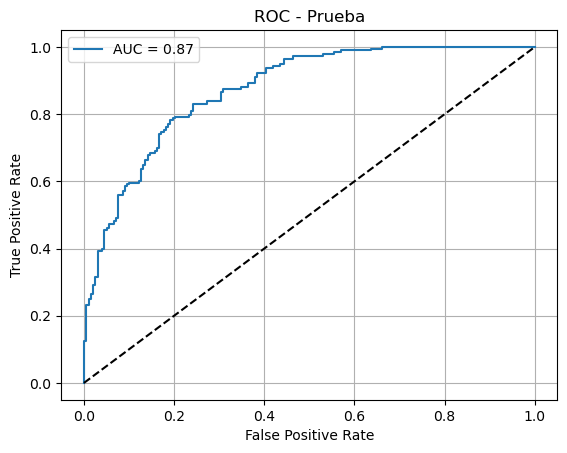

In [6]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, GlobalAveragePooling2D, Concatenate, Dropout
from tensorflow.keras.applications import MobileNetV2
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# ==== CARGA DE DATOS ====
# e1 = pd.read_excel("datos_procesados_empresa1_con_imagen.xlsx")

# ==== CONFIGURACIÓN ====
img_base_dir = r"C:\Users\jupap\OneDrive - Universidad de los andes\Tesis Camiii\ProyectoGradoGEB\imagenes_diarias"
img_size = (224, 224)
batch_size = 32
epochs = 20

# ==== VARIABLES DE TIEMPO A USAR ====
features = ["STD_VOLUME", "ORIG_STD_VOLUME", "ORIG_TEMPERATURE", "TEMPERATURE",
            "PRESSURE", "ORIG_PRESSURE", "RAW_VOLUME", "ORIG_RAW_VOLUME"]
scaler = StandardScaler()
e1[features] = scaler.fit_transform(e1[features])

# ==== AGRUPACIÓN POR DÍA ====
X_img, X_seq, y = [], [], []

for name, group in e1.groupby("image_filename"):
    img_path_normal = os.path.join(img_base_dir, "normal", name)
    img_path_anomalo = os.path.join(img_base_dir, "anomalo", name)

    if os.path.exists(img_path_anomalo):
        img_path = img_path_anomalo
        label = 1
    elif os.path.exists(img_path_normal):
        img_path = img_path_normal
        label = 0
    else:
        continue
    
    with open(img_path, 'rb') as f:
        file_bytes = np.asarray(bytearray(f.read()), dtype=np.uint8)
        img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    if img is None:
        continue
    img = cv2.resize(img, img_size)
    img = img / 255.0

    seq = group[features].values
    if seq.shape[0] < 6:
        continue
    X_img.append(img)
    X_seq.append(seq)
    y.append(label)

# ==== CONVERTIR A NUMPY ====
X_img = np.array(X_img)
X_seq = tf.keras.preprocessing.sequence.pad_sequences(X_seq, padding="post", dtype="float32")
y = np.array(y)

# ==== DIVISIÓN MANUAL (sin train_test_split, sin validation_data) ====
indices = np.arange(len(X_img))
np.random.seed(42)
np.random.shuffle(indices)

X_img = X_img[indices]
X_seq = X_seq[indices]
y = y[indices]

n_total = len(X_img)
n_test = int(0.2 * n_total)
n_val = int(0.2 * (n_total - n_test))  # 20% de entrenamiento restante

# Corte manual
X_test_img = X_img[:n_test]
X_test_seq = X_seq[:n_test]
y_test = y[:n_test]

X_val_img = X_img[n_test:n_test + n_val]
X_val_seq = X_seq[n_test:n_test + n_val]
y_val = y[n_test:n_test + n_val]

X_train_img = X_img[n_test + n_val:]
X_train_seq = X_seq[n_test + n_val:]
y_train = y[n_test + n_val:]

print("✅ Entrenamiento puro:", len(y_train))
print("🔍 Validación:", len(y_val))
print("🧪 Prueba:", len(y_test))

# ==== MODELO CNN + LSTM ====
img_input = Input(shape=(224, 224, 3))
cnn_base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=img_input)
cnn_base.trainable = False
cnn_output = GlobalAveragePooling2D()(cnn_base.output)

seq_input = Input(shape=(X_seq.shape[1], X_seq.shape[2]))
lstm_output = LSTM(64)(seq_input)

fusion = Concatenate()([cnn_output, lstm_output])
x = Dense(128, activation="relu")(fusion)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=[img_input, seq_input], outputs=output)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])


# ==== ENTRENAMIENTO
history = model.fit(
    [X_train_img, X_train_seq], y_train,
    validation_data=([X_val_img, X_val_seq], y_val),  # Incluye validación
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True
)


# GRÁFICAS DE PÉRDIDA Y PRECISIÓN
plt.figure(figsize=(12, 5))

# Gráfica de pérdida
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Pérdida")
plt.legend()

# Gráfica de precisión
plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Precisión")
plt.legend()

plt.show()


# ==== EVALUACIÓN MANUAL EN VALIDACIÓN ====
print("\n🔍 Evaluación en VALIDACIÓN")
y_val_pred_proba = model.predict([X_val_img, X_val_seq])
y_val_pred = (y_val_pred_proba > 0.5).astype(int)
print("Matriz de confusión:")
print(confusion_matrix(y_val, y_val_pred))
print("\nReporte de clasificación:")
print(classification_report(y_val, y_val_pred))

# Curva ROC
fpr, tpr, _ = roc_curve(y_val, y_val_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC - Validación")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

# ==== EVALUACIÓN MANUAL EN PRUEBA ====
print("\n🧪 Evaluación en PRUEBA")
y_test_pred_proba = model.predict([X_test_img, X_test_seq])
y_test_pred = (y_test_pred_proba > 0.5).astype(int)
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_test_pred))
print("\nReporte de clasificación:")
print(classification_report(y_test, y_test_pred))

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC - Prueba")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

# ==== GUARDAR MODELO ====
model.save("modelo_cnn_lstm_particion.h5")


Skipping group with insufficient data: Año2019_Día2019-01-13.png
Epoch 1/20
43/43 [==============================] - 39s 775ms/step - loss: 0.6035 - accuracy: 0.6937 - val_loss: 0.4655 - val_accuracy: 0.7761
Epoch 2/20
43/43 [==============================] - 29s 684ms/step - loss: 0.4622 - accuracy: 0.7646 - val_loss: 0.4556 - val_accuracy: 0.7761
Epoch 3/20
43/43 [==============================] - 31s 731ms/step - loss: 0.4434 - accuracy: 0.7873 - val_loss: 0.4844 - val_accuracy: 0.7455
Epoch 4/20
43/43 [==============================] - 30s 702ms/step - loss: 0.4648 - accuracy: 0.7690 - val_loss: 0.4897 - val_accuracy: 0.7405
Epoch 5/20
43/43 [==============================] - 30s 710ms/step - loss: 0.4400 - accuracy: 0.7785 - val_loss: 0.4195 - val_accuracy: 0.7863
Epoch 6/20
43/43 [==============================] - 30s 709ms/step - loss: 0.4051 - accuracy: 0.8085 - val_loss: 0.4107 - val_accuracy: 0.7964
Epoch 7/20
43/43 [==============================] - 29s 676ms/step - loss: 0.

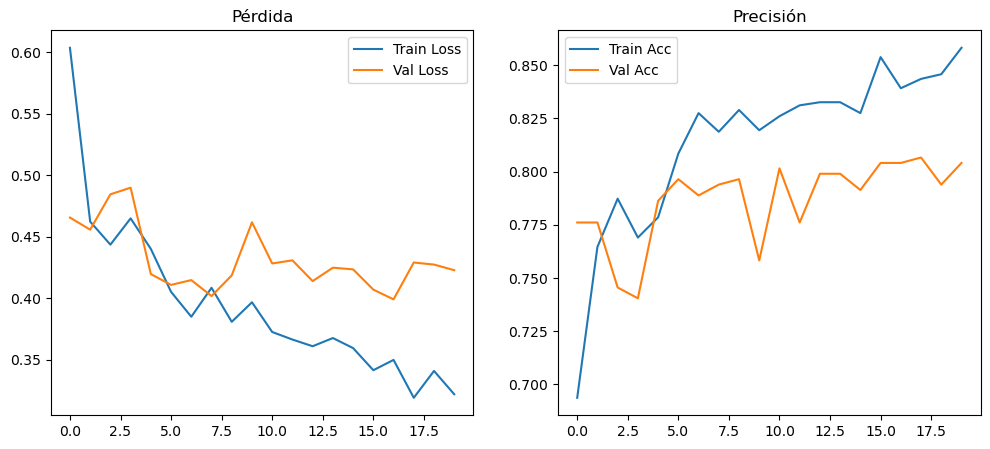

43/43 [==============================] - 26s 550ms/step

📊 Resultados para Train
Matriz de Confusión:
[[596  94]
 [ 72 606]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.89      0.86      0.88       690
           1       0.87      0.89      0.88       678

    accuracy                           0.88      1368
   macro avg       0.88      0.88      0.88      1368
weighted avg       0.88      0.88      0.88      1368



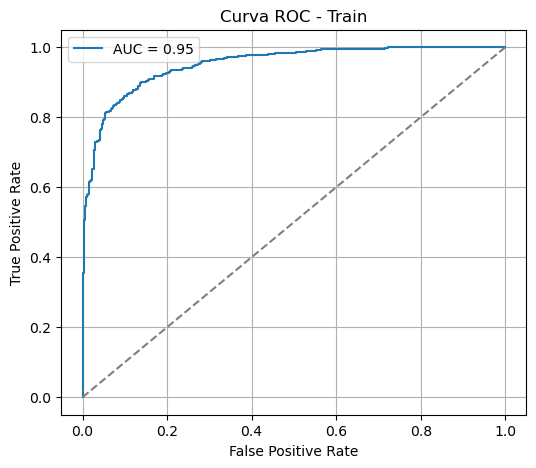

7/7 [==============================] - 4s 492ms/step

📊 Resultados para Test
Matriz de Confusión:
[[75 23]
 [13 83]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.85      0.77      0.81        98
           1       0.78      0.86      0.82        96

    accuracy                           0.81       194
   macro avg       0.82      0.81      0.81       194
weighted avg       0.82      0.81      0.81       194



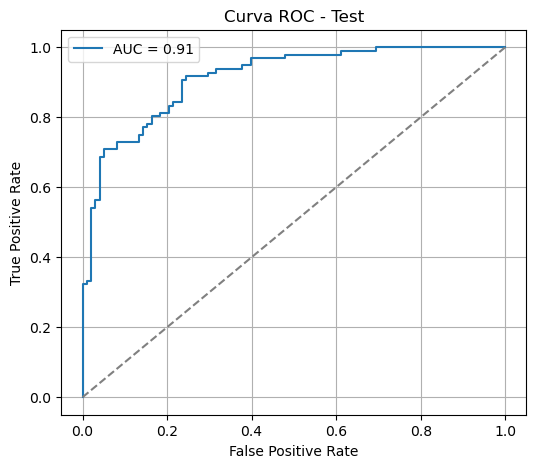

In [6]:
#CORRER -> CON COMENTARIO DE JUAN FERNANDO

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, GlobalAveragePooling2D, Concatenate, Dropout
from tensorflow.keras.applications import MobileNetV2
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# ==== CARGA DE DATOS ====
# Asegúrate de tener e1 ya cargado:
# e1 = pd.read_excel("datos_procesados_empresa1_con_imagen.xlsx")

# ==== CONFIGURACIÓN ====
img_base_dir = r"C:\Users\jupap\OneDrive - Universidad de los andes\Tesis Camiii\ProyectoGradoGEB\imagenes_diarias"  # 📌 Reemplaza con la ruta real
img_size = (224, 224)
batch_size = 32
epochs = 20

# ==== VARIABLES DE TIEMPO A USAR ====
features = ["STD_VOLUME", "ORIG_STD_VOLUME", "ORIG_TEMPERATURE", "TEMPERATURE",
            "PRESSURE", "ORIG_PRESSURE", "RAW_VOLUME", "ORIG_RAW_VOLUME"]
scaler = StandardScaler()
e1[features] = scaler.fit_transform(e1[features])

# ==== AGRUPACIÓN POR DÍA ====
X_img, X_seq, y = [], [], []

for name, group in e1.groupby("image_filename"):
    img_path_normal = os.path.join(img_base_dir, "normal", name)
    img_path_anomalo = os.path.join(img_base_dir, "anomalo", name)

    if os.path.exists(img_path_anomalo):
        img_path = img_path_anomalo
        label = 1
    elif os.path.exists(img_path_normal):
        img_path = img_path_normal
        label = 0
    else:
        print(f"Image not found: {name}")
        continue
    
    with open(img_path, 'rb') as f:
        file_bytes = np.asarray(bytearray(f.read()), dtype=np.uint8)
        img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)

    if img is None: 
        print(f"Failed to load image: {img_path}")
        continue
    img = cv2.resize(img, img_size)
    img = img / 255.0

    seq = group[features].values
    if seq.shape[0] < 6: 
        print(f"Skipping group with insufficient data: {name}")
        continue
    X_img.append(img)
    X_seq.append(seq)
    y.append(label)

# Check if data was loaded successfully
if len(X_img) == 0 or len(X_seq) == 0 or len(y) == 0:
    raise ValueError("No data was loaded. Please check the image paths and data preprocessing steps.")

# ==== CONVERTIR A NUMPY ====
X_img = np.array(X_img)
X_seq = tf.keras.preprocessing.sequence.pad_sequences(X_seq, padding="post", dtype="float32")
y = np.array(y)

# ==== DIVISIÓN DE DATOS ====
# ==== DIVISIÓN DE DATOS ====
X_train_img, X_temp_img, X_train_seq, X_temp_seq, y_train, y_temp = train_test_split(
    X_img, X_seq, y, test_size=0.3, stratify=y, random_state=42)

X_val_img, X_test_img, X_val_seq, X_test_seq, y_val, y_test = train_test_split(
    X_temp_img, X_temp_seq, y_temp, test_size=0.33, stratify=y_temp, random_state=42)


# ==== MODELO CNN + LSTM ====
img_input = Input(shape=(224, 224, 3))
cnn_base = MobileNetV2(include_top=False, weights="imagenet", input_tensor=img_input)
cnn_base.trainable = False
cnn_output = GlobalAveragePooling2D()(cnn_base.output)

seq_input = Input(shape=(X_seq.shape[1], X_seq.shape[2]))
lstm_output = LSTM(64)(seq_input)

fusion = Concatenate()([cnn_output, lstm_output])
x = Dense(128, activation="relu")(fusion)
x = Dropout(0.3)(x)
output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=[img_input, seq_input], outputs=output)
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

# ==== ENTRENAMIENTO ====
history = model.fit(
    [X_train_img, X_train_seq], y_train,
    validation_data=([X_val_img, X_val_seq], y_val),
    epochs=epochs,
    batch_size=batch_size
)

# ==== GRÁFICAS DE PÉRDIDA Y PRECISIÓN ====
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Pérdida")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Acc")
plt.plot(history.history["val_accuracy"], label="Val Acc")
plt.title("Precisión")
plt.legend()
plt.show()

# === MÉTRICAS EN TRAIN Y TEST ===
for name, X_img_set, X_seq_set, y_true in zip(
    ["Train", "Test"],
    [X_train_img, X_test_img],
    [X_train_seq, X_test_seq],
    [y_train, y_test]
):
    y_pred_proba = model.predict([X_img_set, X_seq_set])
    y_pred = (y_pred_proba > 0.5).astype(int)

    print(f"\n📊 Resultados para {name}")
    print("Matriz de Confusión:")
    cm = confusion_matrix(y_true, y_pred)
    print(cm)
    print("\nReporte de Clasificación:")
    print(classification_report(y_true, y_pred))

    # Curva ROC
    fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title(f"Curva ROC - {name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()
    plt.show()

# ==== GUARDAR MODELO ====
model.save("modelo_cnn_lstm_721.h5")